# Scenario comparison

Compares KPIs across all scenarios for which `walcheren_assigned_trips_*.parquet`
files exist in `data/processed/`.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA_DIR = Path("../data/processed")

sns.set_theme(style="whitegrid")

## 1. Load data

In [9]:
trip_files = sorted(DATA_DIR.glob("walcheren_assigned_trips_*.parquet"))
print(f"Found {len(trip_files)} scenario(s):")
for f in trip_files:
    print(" ", f.stem.removeprefix("walcheren_assigned_trips_"))

Found 5 scenario(s):
  baseline
  baseline_haiku
  baseline_seed2
  grok_4_1_fast_non_reasoning
  grok_4_1_fast_reasoning


In [10]:
def load_scenario(path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return (trips, activities) for one scenario parquet pair."""
    scenario = path.stem.removeprefix("walcheren_assigned_trips_")
    trips = pd.read_parquet(path)
    trips["distance"] = trips["distance"].astype(float)
    trips["scenario"] = scenario

    act_path = DATA_DIR / f"walcheren_activities_{scenario}.parquet"
    acts = pd.read_parquet(act_path)
    acts["scenario"] = scenario
    return trips, acts


all_trips_list, all_acts_list = [], []
for f in trip_files:
    t, a = load_scenario(f)
    all_trips_list.append(t)
    all_acts_list.append(a)

trips = pd.concat(all_trips_list, ignore_index=True)
acts = pd.concat(all_acts_list, ignore_index=True)

print(f"Total trips : {len(trips):,}")
print(f"Total agents: {trips['agent_id'].nunique():,}")
trips.head(3)

Total trips : 9,759
Total agents: 1,894


,agent_id,household_id,tour_idx,trip_seq,origin,destination,mode,departure_time,arrival_time,distance,escort_agent_id,mode_reasoning,prompt_mode,route_nodes,origin_buurt,destination_buurt,scenario
0,00fe15b3-7038-4340-a598-1e4788a95319,752,0,0,E0284N3859,E0287N3871,walk,536.978011,None,NaN,None,"Today, I feel like taking it easy and enjoying...","You are Agent 1456, deciding how to travel tod...","[42652637, 42654797, 42655369, 42656017, 42656...",Bonedijkestraat e.o.,Hercules Segherslaan e.o.,baseline
1,00fe15b3-7038-4340-a598-1e4788a95319,752,0,1,E0287N3871,E0290N3851,walk,630.000000,None,NaN,None,"Today, I feel like taking it easy and enjoying...","You are Agent 1456, deciding how to travel tod...","[1446642343, 1711185041, 42681274, 42679611, 4...",Hercules Segherslaan e.o.,Oude Binnenstad,baseline
2,00fe15b3-7038-4340-a598-1e4788a95319,752,0,2,E0290N3851,E0320N3895,walk,765.000000,None,NaN,None,"Today, I feel like taking it easy and enjoying...","You are Agent 1456, deciding how to travel tod...","[42633514, 1546317209, 42635498, 6721026645, 4...",Oude Binnenstad,Reijershove,baseline


## 2. Join trip purpose from activities

Each trip (except the final return-to-home leg of every tour) ends at a non-home
activity.  We identify return trips as the last `trip_seq` within each
`(scenario, agent_id, tour_idx)` group, then assign a cumulative activity index
per agent that aligns with `activity_seq`.

In [11]:
# Mark each trip as return-to-home (last trip_seq in its tour).
max_trip_seq = trips.groupby(["scenario", "agent_id", "tour_idx"])[
    "trip_seq"
].transform("max")
trips["is_return"] = trips["trip_seq"] == max_trip_seq

# Assign cumulative index for non-return trips per (scenario, agent_id).
# Sorting by tour then trip_seq ensures the order matches activity_seq.
non_return = (
    trips[~trips["is_return"]]
    .sort_values(["scenario", "agent_id", "tour_idx", "trip_seq"])
    .copy()
)
non_return["activity_seq"] = non_return.groupby(["scenario", "agent_id"]).cumcount()

# Join activity_type from activities.
purpose_trips = non_return.merge(
    acts[["scenario", "agent_id", "activity_seq", "activity_type"]],
    on=["scenario", "agent_id", "activity_seq"],
    how="left",
)

print(f"Non-return trips       : {len(non_return):,}")
print(f"Matched with purpose   : {purpose_trips['activity_type'].notna().sum():,}")
purpose_trips[
    [
        "scenario",
        "agent_id",
        "tour_idx",
        "trip_seq",
        "mode",
        "distance",
        "activity_type",
    ]
].head(6)

Non-return trips       : 7,858
Matched with purpose   : 6,634


,scenario,agent_id,tour_idx,trip_seq,mode,distance,activity_type
0,baseline,00fe15b3-7038-4340-a598-1e4788a95319,0,0,walk,NaN,leisure
1,baseline,00fe15b3-7038-4340-a598-1e4788a95319,0,1,walk,NaN,eating_out
2,baseline,00fe15b3-7038-4340-a598-1e4788a95319,0,2,walk,NaN,leisure
3,baseline,00fe15b3-7038-4340-a598-1e4788a95319,0,3,walk,NaN,shopping
4,baseline,01f0c4a5-48c1-455a-9b0a-bd0a6b80226a,0,0,bike,NaN,school
5,baseline,01f0c4a5-48c1-455a-9b0a-bd0a6b80226a,0,1,bike,NaN,shopping


## 3. KPI: mode share

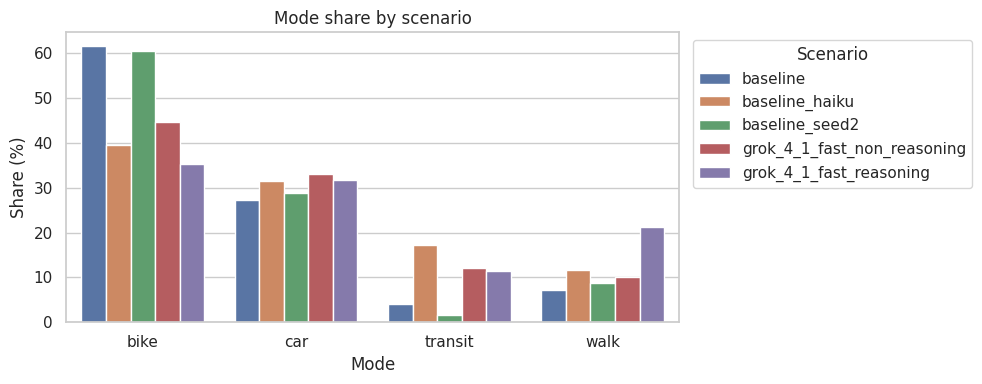

In [12]:
mode_share = trips.groupby(["scenario", "mode"]).size().reset_index(name="count")
mode_share["share"] = mode_share.groupby("scenario")["count"].transform(
    lambda x: x / x.sum() * 100
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(
    data=mode_share,
    x="mode",
    y="share",
    hue="scenario",
    ax=ax,
)
ax.set_title("Mode share by scenario")
ax.set_xlabel("Mode")
ax.set_ylabel("Share (%)")
ax.legend(title="Scenario", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4. KPI: trip rate

In [13]:
trip_rate = (
    trips.groupby("scenario")
    .apply(
        lambda df: pd.Series(
            {
                "total_trips": len(df),
                "unique_agents": df["agent_id"].nunique(),
                "trip_rate": len(df) / df["agent_id"].nunique(),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

trip_rate.style.format(
    {"total_trips": "{:,.0f}", "unique_agents": "{:,.0f}", "trip_rate": "{:.2f}"}
).set_caption("Trip rate per scenario")

,scenario,total_trips,unique_agents,trip_rate
0,baseline,"2,410",419,5.75
1,baseline_haiku,"1,750",333,5.26
2,baseline_seed2,"2,392",419,5.71
3,grok_4_1_fast_non_reasoning,"1,640",367,4.47
4,grok_4_1_fast_reasoning,"1,567",356,4.40


## 5. KPI: trip length distribution

In [14]:
dist_data = trips.dropna(subset=["distance"]).copy()
dist_data["distance_km"] = dist_data["distance"] / 1000

if dist_data.empty:
    print("No distance data available — skipping trip length plots.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Box plot
    scenarios = dist_data["scenario"].unique()
    box_data = [
        dist_data.loc[dist_data["scenario"] == s, "distance_km"].values
        for s in scenarios
    ]
    axes[0].boxplot(box_data, tick_labels=list(scenarios), showfliers=False)
    axes[0].set_title("Trip length — box plot (no outliers)")
    axes[0].set_ylabel("Distance (km)")
    axes[0].tick_params(axis="x", rotation=30)

    # KDE
    for scenario, grp in dist_data.groupby("scenario"):
        grp["distance_km"].plot.kde(ax=axes[1], label=scenario, bw_method=0.3)
    axes[1].set_title("Trip length — KDE")
    axes[1].set_xlabel("Distance (km)")
    axes[1].set_xlim(left=0)
    axes[1].legend(title="Scenario", bbox_to_anchor=(1.01, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

No distance data available — skipping trip length plots.


## 6. KPI: trips per purpose

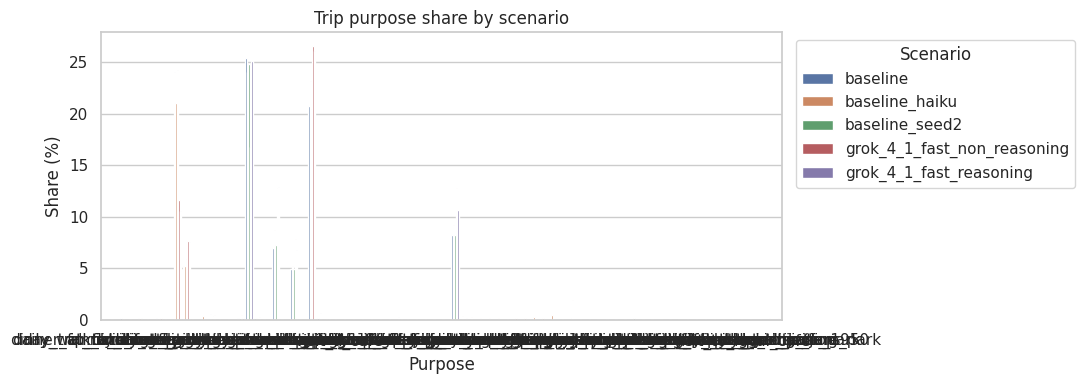

In [15]:
purpose_share = (
    purpose_trips.dropna(subset=["activity_type"])
    .groupby(["scenario", "activity_type"])
    .size()
    .reset_index(name="count")
)
purpose_share["share"] = purpose_share.groupby("scenario")["count"].transform(
    lambda x: x / x.sum() * 100
)

fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(
    data=purpose_share,
    x="activity_type",
    y="share",
    hue="scenario",
    ax=ax,
)
ax.set_title("Trip purpose share by scenario")
ax.set_xlabel("Purpose")
ax.set_ylabel("Share (%)")
ax.legend(title="Scenario", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()